# Visual Product Search Engine
**Visual Recognition Course Project**

Roll Numbers: 13, 69, 91  
Seeds used for reproducibility: `[13, 69, 91]`

---
## Notebook Structure
1. **Global Configuration** — all tunable variables in one place  
2. **Environment Setup** — installs, Drive mount  
3. **Dataset Creation** — extract + split images  
4. **Stage 1** — Product Localisation (YOLO) for train / gallery / query  
5. **Stage 2** — Caption Generation (BLIP-2) for train / gallery / query  
6. **Stage 3** — CLIP Fine-Tuning (contrastive, triplet loss)  
7. **Stage 4** — Gallery Embedding (offline indexing)  
8. **Stage 5** — HNSW Index Construction  
9. **Stage 6** — Online Query Retrieval  
10. **Stage 7** — BLIP-2 Re-ranking  
11. **Stage 8** — Ablation Study (A / B / C)  
12. **Stage 9** — Batch Evaluation with mean ± std over seeds  
13. **SearchEngine Class** — clean API for Streamlit integration  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔧 Global Configuration
> **Change all paths and hyperparameters here. No need to edit cells below.**

In [ ]:
import os

# ══════════════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION  — edit only this cell
# ══════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────
DRIVE_BASE       = "/content/drive/MyDrive/Study/VR/Final_Project/Dataset"
IMG_ZIP          = os.path.join(DRIVE_BASE, "Img", "img.zip")
EVAL_FILE        = os.path.join(DRIVE_BASE, "Eval", "list_eval_partition.txt")

EXTRACT_PATH     = "/content"
DATASET_PATH     = "/content/dataset"          # train / query / gallery
CROPPED_PATH     = "/content/cropped"          # YOLO-cropped versions (local, temporary)
DEST_CROPPED_PATH = "/content/drive/MyDrive/Study/VR/Final_Project/saved/cropped" # YOLO-cropped versions (persistent, on Drive)
DEST_CROPPED_ZIP_PATH = "/content/drive/MyDrive/Study/VR/Final_Project/saved/cropped/cropped.zip"
CAPTIONS_TRAIN   = "/content/drive/MyDrive/Study/VR/Final_Project/saved/captions_train.csv"
CAPTIONS_GALLERY = "/content/drive/MyDrive/Study/VR/Final_Project/saved/captions_gallery.csv"
CAPTIONS_QUERY   = "/content/drive/MyDrive/Study/VR/Final_Project/saved/captions_query.csv"
MAPPING_CSV      = "/content/drive/MyDrive/Study/VR/Final_Project/saved/mapping.csv"

FINETUNED_CLIP_PATH = "/content/drive/MyDrive/Study/VR/Final_Project/saved/clip_finetuned"
CHECKPOINT_PATH     = "/content/drive/MyDrive/Study/VR/Final_Project/saved/clip_checkpoints"
EMBEDDINGS_PATH     = "/content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings"

# ── Models ────────────────────────────────────────────────────
YOLO_MODEL       = "yolov8n.pt"          # yolov8s/m for better accuracy
CLIP_MODEL_NAME  = "openai/clip-vit-base-patch32"
BLIP_MODEL_NAME  = "Salesforce/blip2-flan-t5-xl"

# ── CLIP Fine-tuning ──────────────────────────────────────────
CLIP_FINETUNE_EPOCHS    = 5
CLIP_FINETUNE_LR        = 1e-5
CLIP_FINETUNE_BATCH     = 32
CLIP_UNFREEZE_BLOCKS    = 4        # last N vision transformer blocks to unfreeze
CLIP_TEMPERATURE        = 0.07     # InfoNCE temperature τ
CLIP_MARGIN             = 0.3      # (unused; kept for reference)

# ── Subsampling controls ──────────────────────────────────────
# Set to None to use ALL images; set to an integer to use a random subset.
# Recommended for a course project on Colab T4:
#   BLIP-2 on 52k images = ~5 hrs. Use subsets to stay within session limits.
#   Gallery must be fully captioned/embedded (it is your search database).
#   Train captions only needed for fine-tuning; a subset of items is enough.
#   Evaluation subsample is standard practice in retrieval literature.
CAPTION_SUBSAMPLE_TRAIN   = 10000   # items to caption for fine-tuning data  (None = all 26k)
CAPTION_SUBSAMPLE_GALLERY = None   # KEEP None — full gallery = better search index
CAPTION_SUBSAMPLE_QUERY   = 2000   # queries for evaluation subsample         (None = all 14k)
FINETUNE_MAX_ITEMS        = 3000   # max unique item_ids used in fine-tuning   (None = all items)
EVAL_SUBSAMPLE            = 1000   # queries used per seed in ablation eval    (None = full query set)

# ── Embedding fusion ──────────────────────────────────────────
# alpha = 1.0  → vision only  (Ablation A)
# Two alpha values are tested in B and C as required by the project statement
ALPHA_ABLATION_B1 = 0.7   # first  α for Config B (frozen CLIP + BLIP-2)
ALPHA_ABLATION_B2 = 0.5   # second α for Config B
ALPHA_ABLATION_C1 = 0.7   # first  α for Config C (fine-tuned CLIP + BLIP-2)
ALPHA_ABLATION_C2 = 0.5   # second α for Config C

# ── Retrieval ─────────────────────────────────────────────────
TOP_K            = 15
K_VALUES         = [5, 10, 15]
HNSW_M           = 32
HNSW_EF_CONSTRUCTION = 200
HNSW_EF_SEARCH   = 50

# ── Reproducibility ───────────────────────────────────────────
SEEDS            = [13, 69, 91]   # roll numbers used as seeds
DEFAULT_SEED     = SEEDS[0]

RESUME_FROM_CHECKPOINT  = f"checkpoint_latest_seed_{DEFAULT_SEED}.pt"     # e.g. "checkpoint_latest_seed_13.pt" to resume; None = start fresh


# ── Caption generation ────────────────────────────────────────
CAPTION_MAX_TOKENS = 30
CAPTION_PROMPT     = "Describe only the clothing item in detail"
BLIP_BATCH_SIZE    = 16   # safe for T4 with float16; reduce to 8 if OOM

# ── Create directories ────────────────────────────────────────
for d in [EMBEDDINGS_PATH, CHECKPOINT_PATH, CROPPED_PATH, DEST_CROPPED_PATH]:
    os.makedirs(d, exist_ok=True)

print("✅ Configuration loaded")
print(f"   Caption subsampling  — train: {CAPTION_SUBSAMPLE_TRAIN}, "
      f"gallery: {CAPTION_SUBSAMPLE_GALLERY}, query: {CAPTION_SUBSAMPLE_QUERY}")
print(f"   Fine-tune max items  — {FINETUNE_MAX_ITEMS}")
print(f"   Eval subsample/seed  — {EVAL_SUBSAMPLE}")

✅ Configuration loaded
   Caption subsampling  — train: 10000, gallery: None, query: 2000
   Fine-tune max items  — 3000
   Eval subsample/seed  — 1000


## 1. Environment Setup

In [ ]:
!pip install -q ultralytics transformers accelerate faiss-cpu einops

In [ ]:
import os, random, shutil, pickle, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm   # Colab/Jupyter inline progress bar
import matplotlib.pyplot as plt
import faiss
import cv2
from ultralytics import YOLO
from transformers import (
    CLIPProcessor, CLIPModel,
    Blip2Processor, Blip2ForConditionalGeneration
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"CUDA: {torch.cuda.is_available()}")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(DEFAULT_SEED)
print(f"✅ Seed set to {DEFAULT_SEED}")


Device: cuda
CUDA: True
✅ Seed set to 13


## 2. Dataset Creation
### 2.1 Extract Images

In [ ]:
import zipfile

# os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(IMG_ZIP, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("✅ Images extracted to", EXTRACT_PATH)


✅ Images extracted to /content


### Delete Directory

This cell demonstrates how to delete a directory. **Be careful when using this command as it permanently removes files.**

In [ ]:
# import shutil

# DIR_TO_DELETE = '/content/img'

# if os.path.exists(DIR_TO_DELETE):
#     shutil.rmtree(DIR_TO_DELETE)
#     print(f"✅ Directory '{DIR_TO_DELETE}' deleted.")
# else:
#     print(f"Directory '{DIR_TO_DELETE}' does not exist.")

### 2.2 Parse Partition File and Build train / query / gallery

In [ ]:
with open(EVAL_FILE, 'r') as f:
    lines = f.readlines()

data = []
for line in lines[2:]:   # skip 2-line header
    parts = line.strip().split()
    if len(parts) < 3:
        continue
    img_path, item_id, split = parts[0], parts[1], parts[2]
    data.append((img_path, item_id, split))

print(f"Total records: {len(data)}")
print("Sample:", data[:3])


Total records: 52712
Sample: [('img/WOMEN/Dresses/id_00000002/02_1_front.jpg', 'id_00000002', 'train'), ('img/WOMEN/Dresses/id_00000002/02_2_side.jpg', 'id_00000002', 'train'), ('img/WOMEN/Dresses/id_00000002/02_4_full.jpg', 'id_00000002', 'train')]


In [ ]:
for split in ["train", "query", "gallery"]:
    os.makedirs(os.path.join(DATASET_PATH, split), exist_ok=True)

mapping = []
for img_path_orig, item_id, split in tqdm(data, desc="Copying images"):
    src = os.path.join(EXTRACT_PATH, img_path_orig)

    # Generate a unique filename by replacing slashes and removing 'img/' prefix
    # Example: 'img/WOMEN/Dresses/id_00000002/02_1_front.jpg' -> 'WOMEN_Dresses_id_00000002_02_1_front.jpg'
    unique_img_name = img_path_orig.replace('img/', '').replace('/', '_')

    dst = os.path.join(DATASET_PATH, split, unique_img_name)
    if os.path.exists(src):
        shutil.copy(src, dst)
        mapping.append({"image_path": dst, "image_name": unique_img_name,
                        "item_id": item_id, "split": split})

df_map = pd.DataFrame(mapping)
df_map.to_csv(MAPPING_CSV, index=False)

print(f"Train:   {len(os.listdir(DATASET_PATH+'/train'))}")
print(f"Query:   {len(os.listdir(DATASET_PATH+'/query'))}")
print(f"Gallery: {len(os.listdir(DATASET_PATH+'/gallery'))}")
print("✅ mapping.csv saved")

Copying images:   0%|          | 0/52712 [00:00<?, ?it/s]

Train:   25882
Query:   14218
Gallery: 12612
✅ mapping.csv saved


## 3. Stage 1 — Product Localisation (YOLO)
### 3.1 Load YOLO Model

In [ ]:
yolo_model = YOLO(YOLO_MODEL)
print(f"✅ YOLO model loaded: {YOLO_MODEL}")


✅ YOLO model loaded: yolov8n.pt


### 3.2 YOLO Crop Utility

In [ ]:
def yolo_crop(image_path: str) -> Image.Image:
    """
    Detect the primary person/clothing item and return the cropped PIL image.
    Falls back to the full image if no detection.
    This function is reused for train, gallery, and query.
    """
    results = yolo_model(image_path, verbose=False)
    boxes = results[0].boxes

    if len(boxes) == 0:
        return Image.open(image_path).convert("RGB")

    # pick the largest bounding box (most prominent item)
    areas = [(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1])
             for b in boxes]
    best = int(np.argmax(areas))
    x1, y1, x2, y2 = map(int, boxes[best].xyxy[0].tolist())

    img = Image.open(image_path).convert("RGB")
    return img.crop((x1, y1, x2, y2))

def crop_folder(src_dir, dst_dir, label=""):
    os.makedirs(dst_dir, exist_ok=True)
    files = [f for f in os.listdir(src_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    skipped = 0

    for fname in tqdm(files, desc=label):
        dst = os.path.join(dst_dir, fname)
        if os.path.exists(dst):          # resume-friendly
            continue
        src = os.path.join(src_dir, fname)
        try:
            results = yolo_model(src, verbose=False)
            boxes   = results[0].boxes

            img = Image.open(src).convert("RGB")

            if len(boxes) > 0:
                # Use highest-confidence box
                best = int(boxes.conf.argmax())
                x1, y1, x2, y2 = map(int, boxes.xyxy[best].tolist())
                w, h = img.size
                x1,y1,x2,y2 = max(0,x1),max(0,y1),min(w,x2),min(h,y2)
                img = img.crop((x1, y1, x2, y2))
            else:
                skipped += 1   # count but DON'T skip — use full image

            img.save(dst)

        except Exception as e:
            continue

    print(f"[{label}] Done — {len(files)} images, "
          f"{skipped} used full image (no detection)")

### 3.3 Crop All Splits (train / gallery / query)

In [ ]:
crop_folder(DATASET_PATH+"/train",   CROPPED_PATH+"/train",   "Crop train")
crop_folder(DATASET_PATH+"/gallery", CROPPED_PATH+"/gallery", "Crop gallery")
crop_folder(DATASET_PATH+"/query",   CROPPED_PATH+"/query",   "Crop query")
print("✅ All splits cropped")


Crop train:   0%|          | 0/25882 [00:00<?, ?it/s]

[Crop train] Done — 25882 images, 649 used full image (no detection)


Crop gallery:   0%|          | 0/12612 [00:00<?, ?it/s]

[Crop gallery] Done — 12612 images, 257 used full image (no detection)


Crop query:   0%|          | 0/14218 [00:00<?, ?it/s]

[Crop query] Done — 14218 images, 463 used full image (no detection)
✅ All splits cropped


### 3.4 Save Cropped Images to Drive

This step saves the YOLO-cropped images to Google Drive for persistence and to avoid re-cropping in future sessions.

In [ ]:
# # This cell's original logic is now handled in section 3.3 (cell HmMuO-elsFd9)
# # Remove existing destination if it's a directory to ensure a clean copy
# if os.path.exists(CROPPED_PATH) and os.path.isdir(CROPPED_PATH):
#     shutil.rmtree(CROPPED_PATH)

# # Copy the entire cropped directory to Google Drive
# shutil.copytree(CROPPED_PATH, DEST_CROPPED_PATH)
# print(f"✅ Cropped images copied to {DEST_CROPPED_PATH}")

In [ ]:
print(f"Gallery: {len(os.listdir(CROPPED_PATH+'/gallery'))}")
print(f"Train:   {len(os.listdir(CROPPED_PATH+'/train'))}")
print(f"Query:   {len(os.listdir(CROPPED_PATH+'/query'))}")


Gallery: 12612
Train:   25882
Query:   14218


## 4. Stage 2 — Caption Generation (BLIP-2)
### 4.1 Load BLIP-2

In [ ]:
blip_processor = Blip2Processor.from_pretrained(BLIP_MODEL_NAME)
blip_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP_MODEL_NAME, torch_dtype=torch.float16
).to(device)
blip_model.eval()
print("✅ BLIP-2 loaded")


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ BLIP-2 loaded


### 4.2 Batched Caption Generator

In [ ]:
def generate_captions(image_dir: str,
                      output_csv: str,
                      batch_size: int = BLIP_BATCH_SIZE,
                      prompt: str = CAPTION_PROMPT,
                      subsample: int = None) -> dict:
    """
    Generate BLIP-2 captions for images in image_dir.
    Saves results to output_csv (Drive path) — skips generation if file exists.
    Returns dict {image_name: caption}.

    subsample: if set, randomly choose this many images (reproducible via DEFAULT_SEED).
               Use CAPTION_SUBSAMPLE_TRAIN / _QUERY from config.
               Always keep CAPTION_SUBSAMPLE_GALLERY = None (full gallery needed).
    """
    if os.path.exists(output_csv):
        df = pd.read_csv(output_csv)
        print(f"Loaded cached captions from {output_csv} ({len(df)} rows)")
        return dict(zip(df["image_name"], df["caption"]))

    all_names = sorted(os.listdir(image_dir))

    # ── Subsample if requested ─────────────────────────────────
    if subsample is not None and subsample < len(all_names):
        rng = random.Random(DEFAULT_SEED)
        names = rng.sample(all_names, subsample)
        print(f"Subsampling {subsample} / {len(all_names)} images from {os.path.basename(image_dir)}")
    else:
        names = all_names
        print(f"Using all {len(names)} images from {os.path.basename(image_dir)}")

    results = []
    for i in tqdm(range(0, len(names), batch_size),
                  desc=f"Captions [{os.path.basename(image_dir)}]"):
        batch_names = names[i:i+batch_size]
        images, valid = [], []
        for n in batch_names:
            try:
                images.append(Image.open(os.path.join(image_dir, n)).convert("RGB"))
                valid.append(n)
            except Exception:
                pass
        if not images:
            continue

        inputs = blip_processor(
            images=images,
            text=[prompt] * len(images),
            return_tensors="pt",
            padding=True
        ).to(device, torch.float16)

        with torch.no_grad():
            gen_ids = blip_model.generate(**inputs, max_new_tokens=CAPTION_MAX_TOKENS)

        captions = blip_processor.batch_decode(gen_ids, skip_special_tokens=True)
        results.extend(zip(valid, captions))
        del inputs
        torch.cuda.empty_cache()

    df = pd.DataFrame(results, columns=["image_name", "caption"])
    df.to_csv(output_csv, index=False)
    print(f"✅ Captions saved → {output_csv}  ({len(df)} rows)")
    return dict(zip(df["image_name"], df["caption"]))


print("✅ generate_captions defined")


✅ generate_captions defined


### 4.3 Generate Captions for All Splits

In [ ]:
# train_captions   = generate_captions(CROPPED_PATH+"/train",   CAPTIONS_TRAIN)
# gallery_captions = generate_captions(CROPPED_PATH+"/gallery", CAPTIONS_GALLERY)
# query_captions   = generate_captions(CROPPED_PATH+"/query",   CAPTIONS_QUERY)


In [ ]:
# ── GPU strongly recommended for BLIP-2 ──────────────────────────────────
# BLIP-2 (blip2-flan-t5-xl) is a ~4B param model.
# On CPU:  ~30-60s per image → 52k images ≈ weeks
# On T4 GPU (float16, batch=16): ~0.3s per image → 52k images ≈ 4-5 hours
# With subsampling (recommended): train=5k → ~25 min, query=2k → ~10 min
#
# Colab free tier gives you ~12h session. Plan:
#   Session 1: crop all (fast) + gallery captions (12k, ~1h)  → save to Drive
#   Session 2: train captions (5k, ~25min) + fine-tune CLIP   → save to Drive
#   Session 3: query captions (2k, ~10min) + eval             → load from Drive

train_captions   = generate_captions(
    "/content/cropped/train",
    CAPTIONS_TRAIN,
    subsample=CAPTION_SUBSAMPLE_TRAIN    # 5000 by default; set None for all 26k
)
gallery_captions = generate_captions(
    "/content/cropped/gallery",
    CAPTIONS_GALLERY,
    subsample=CAPTION_SUBSAMPLE_GALLERY  # None = use all 12k (recommended)
)
query_captions   = generate_captions(
    "/content/cropped/query",
    CAPTIONS_QUERY,
    subsample=CAPTION_SUBSAMPLE_QUERY    # 2000 by default; set None for all 14k
)

print(f"\nTrain captions:   {len(train_captions)}")
print(f"Gallery captions: {len(gallery_captions)}")
print(f"Query captions:   {len(query_captions)}")


Loaded cached captions from /content/drive/MyDrive/Study/VR/Final_Project/saved/captions_train.csv (10000 rows)
Loaded cached captions from /content/drive/MyDrive/Study/VR/Final_Project/saved/captions_gallery.csv (12612 rows)
Loaded cached captions from /content/drive/MyDrive/Study/VR/Final_Project/saved/captions_query.csv (2000 rows)

Train captions:   10000
Gallery captions: 12612
Query captions:   2000


## 5. Stage 3 — CLIP Fine-Tuning
> Fine-tunes the CLIP **vision encoder** (last `CLIP_UNFREEZE_BLOCKS` blocks)  
> using an **InfoNCE contrastive loss** over same-item image pairs.  
> The text encoder stays frozen throughout.


### 5.1 Dataset for Fine-Tuning (same-item pairs)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FashionPairDataset(Dataset):
    """
    Returns (anchor, positive) image pairs sharing the same item_id.
    Used for contrastive fine-tuning of the CLIP vision encoder.

    FINETUNE_MAX_ITEMS caps the number of unique item_ids used,
    which controls training time without changing the pair-sampling logic.
    E.g. 3000 items with ~4 images each → ~24k pairs → manageable on T4.
    """
    def __init__(self, mapping_csv: str, cropped_dir: str,
                 split: str = "train",
                 max_items: int = FINETUNE_MAX_ITEMS,
                 transform=None):
        df = pd.read_csv(mapping_csv)
        df = df[df["split"] == split].copy()

        groups = df.groupby("item_id")["image_name"].apply(list)

        # ── Subsample items if requested ──────────────────────
        item_ids = list(groups.index)
        if max_items is not None and max_items < len(item_ids):
            rng = random.Random(DEFAULT_SEED)
            item_ids = rng.sample(item_ids, max_items)
            print(f"FashionPairDataset: using {max_items} / {len(groups)} items")
        else:
            print(f"FashionPairDataset: using all {len(item_ids)} items")

        self.pairs = []
        for item_id in item_ids:
            imgs = groups[item_id]
            imgs = [n for n in imgs if os.path.exists(os.path.join(cropped_dir, n))]
            if len(imgs) >= 2:
                for i in range(len(imgs)):
                    for j in range(i+1, len(imgs)):
                        self.pairs.append((imgs[i], imgs[j], item_id))

        print(f"FashionPairDataset: {len(self.pairs):,} pairs total")

        self.cropped_dir = cropped_dir
        self.transform   = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.48145466, 0.4578275, 0.40821073],
                                  [0.26862954, 0.26130258, 0.27577711])
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        n1, n2, item_id = self.pairs[idx]
        img1 = Image.open(os.path.join(self.cropped_dir, n1)).convert("RGB")
        img2 = Image.open(os.path.join(self.cropped_dir, n2)).convert("RGB")
        return self.transform(img1), self.transform(img2), item_id


print("✅ FashionPairDataset defined")


✅ FashionPairDataset defined


### 5.2 InfoNCE Contrastive Loss

In [ ]:
class InfoNCELoss(nn.Module):
    """
    Symmetric InfoNCE loss (as used in original CLIP paper).
    temperature: τ parameter controlling sharpness.
    """
    def __init__(self, temperature: float = CLIP_TEMPERATURE):
        super().__init__()
        self.temp = temperature

    def forward(self, emb1: torch.Tensor, emb2: torch.Tensor) -> torch.Tensor:
        # both: (B, D), already normalised
        emb1 = F.normalize(emb1, dim=-1)
        emb2 = F.normalize(emb2, dim=-1)
        B = emb1.size(0)
        logits = (emb1 @ emb2.T) / self.temp     # (B, B)
        labels = torch.arange(B, device=emb1.device)
        loss_i = F.cross_entropy(logits,   labels)
        loss_t = F.cross_entropy(logits.T, labels)
        return (loss_i + loss_t) / 2.0

print("✅ InfoNCELoss defined")


✅ InfoNCELoss defined


### 5.3 Freeze / Unfreeze Helper

In [ ]:
def unfreeze_clip_vision_encoder(model: CLIPModel, n_blocks: int = CLIP_UNFREEZE_BLOCKS):
    """
    Freeze the entire CLIP model, then unfreeze the last n_blocks of the
    vision transformer and the visual_projection layer.
    Text encoder stays frozen.
    """
    # freeze everything
    for p in model.parameters():
        p.requires_grad_(False)

    # unfreeze last n_blocks of vision encoder
    vision_layers = model.vision_model.encoder.layers
    for layer in vision_layers[-n_blocks:]:
        for p in layer.parameters():
            p.requires_grad_(True)

    # unfreeze post-norm and projection
    for p in model.vision_model.post_layernorm.parameters():
        p.requires_grad_(True)
    for p in model.visual_projection.parameters():
        p.requires_grad_(True)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

print("✅ unfreeze_clip_vision_encoder defined")


✅ unfreeze_clip_vision_encoder defined


### 5.4 Fine-Tuning Loop

In [ ]:
def finetune_clip(seed: int = DEFAULT_SEED,
                  save_path: str = FINETUNED_CLIP_PATH,
                  checkpoint_dir: str = CHECKPOINT_PATH,
                  resume_checkpoint: str = RESUME_FROM_CHECKPOINT) -> CLIPModel:
    """
    Fine-tune CLIP vision encoder with InfoNCE contrastive loss.

    Checkpoint saving:
      - After every epoch: {checkpoint_dir}/checkpoint_epoch_{N}_seed_{seed}.pt
        Contains: model weights, optimizer state, scheduler state, loss history.
      - After all epochs: {save_path}/ in HuggingFace format (for inference).

    Resume training:
      - Set RESUME_FROM_CHECKPOINT = "checkpoint_latest_seed_13.pt" in config cell.
      - Set RESUME_FROM_CHECKPOINT = None to start fresh.
      - If final model already exists and resume=None, loads it directly (no re-training).

    GPU required: CLIP fine-tuning on CPU is impractically slow.
    """
    # ── Load final model if already done ──────────────────────
    if os.path.exists(save_path) and resume_checkpoint is None:
        print(f"Loading cached fine-tuned CLIP from {save_path}")
        model = CLIPModel.from_pretrained(save_path).to(device)
        model.eval()
        return model

    set_seed(seed)

    # ── Load model (from checkpoint or from scratch) ───────────
    if resume_checkpoint is not None:
        ckpt_path = os.path.join(checkpoint_dir, resume_checkpoint)
        print(f"Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        start_epoch   = ckpt["epoch"] + 1   # continue after saved epoch
        loss_history  = ckpt.get("loss_history", [])
        print(f"  Resuming from epoch {start_epoch}")
    else:
        model        = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
        start_epoch  = 0
        loss_history = []

    unfreeze_clip_vision_encoder(model, CLIP_UNFREEZE_BLOCKS)
    model.train()

    # ── Dataset and DataLoader ────────────────────────────────
    dataset = FashionPairDataset(MAPPING_CSV, CROPPED_PATH+"/train",
                                  max_items=FINETUNE_MAX_ITEMS)
    loader  = DataLoader(dataset, batch_size=CLIP_FINETUNE_BATCH,
                         shuffle=True, num_workers=2, pin_memory=True,
                         drop_last=True)   # drop_last avoids batch-size-1 edge cases

    # ── Optimizer and scheduler ───────────────────────────────
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CLIP_FINETUNE_LR, weight_decay=1e-4
    )
    remaining_epochs = CLIP_FINETUNE_EPOCHS - start_epoch
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=remaining_epochs * len(loader)
    )

    # ── Restore optimizer state if resuming ──────────────────
    if resume_checkpoint is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if "scheduler_state_dict" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        print("  Optimizer and scheduler state restored")

    criterion = InfoNCELoss(temperature=CLIP_TEMPERATURE)

    # ── Training loop ─────────────────────────────────────────
    for epoch in range(start_epoch, CLIP_FINETUNE_EPOCHS):
        model.train()
        total_loss = 0.0

        for img1, img2, _ in tqdm(loader,
                                   desc=f"Epoch {epoch+1}/{CLIP_FINETUNE_EPOCHS}",
                                   leave=False):
            img1, img2 = img1.to(device), img2.to(device)

            def encode_vision(pixels):
                out = model.vision_model(pixel_values=pixels)
                return model.visual_projection(out.pooler_output)

            emb1 = encode_vision(img1)
            emb2 = encode_vision(img2)
            loss = criterion(emb1, emb2)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        loss_history.append(avg)
        print(f"\n{'─'*40}")
        print(f"Epoch [{epoch+1}/{CLIP_FINETUNE_EPOCHS}]  Loss: {avg:.4f}")
        print(f"{'─'*40}")

        # ── Save checkpoint to Drive ──────────────────────────
        ckpt_name = os.path.join(checkpoint_dir,
                                  f"checkpoint_latest_seed_{seed}.pt") # Modified line
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "loss_history"        : loss_history,
            "seed"                : seed,
        }, ckpt_name)
        print(f"  ✅ Checkpoint → {ckpt_name}")

    # ── Save final model in HuggingFace format ────────────────
    os.makedirs(save_path, exist_ok=True)
    model.save_pretrained(save_path)
    with open(os.path.join(save_path, "loss_history.json"), "w") as f:
        json.dump(loss_history, f)
    print(f"\n✅ Fine-tuned CLIP saved → {save_path}")
    model.eval()
    return model


print("✅ finetune_clip defined")

✅ finetune_clip defined


### 5.5 Run Fine-Tuning

Resuming from checkpoint: /content/drive/MyDrive/Study/VR/Final_Project/saved/clip_checkpoints/checkpoint_latest_seed_13.pt


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Resuming from epoch 2
Trainable params: 28,746,240 / 151,277,313 (19.0%)
FashionPairDataset: using 3000 / 3997 items
FashionPairDataset: 117,173 pairs total
  Optimizer and scheduler state restored


Epoch 3/5:   0%|          | 0/3661 [00:00<?, ?it/s]

...


────────────────────────────────────────
Epoch [4/5]  Loss: 0.2956
────────────────────────────────────────
  ✅ Checkpoint → /content/drive/MyDrive/Study/VR/Final_Project/saved/clip_checkpoints/checkpoint_latest_seed_13.pt


Epoch 5/5:   0%|          | 0/3661 [00:00<?, ?it/s]


────────────────────────────────────────
Epoch [5/5]  Loss: 0.3058
────────────────────────────────────────
  ✅ Checkpoint → /content/drive/MyDrive/Study/VR/Final_Project/saved/clip_checkpoints/checkpoint_latest_seed_13.pt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuned CLIP saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/clip_finetuned


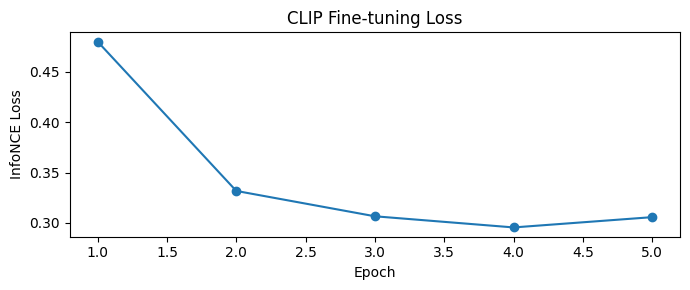

In [ ]:
# ── Run fine-tuning (skipped automatically if cache exists) ──
clip_finetuned = finetune_clip(seed=DEFAULT_SEED, save_path=FINETUNED_CLIP_PATH)

# Plot loss curve if available
loss_file = os.path.join(FINETUNED_CLIP_PATH, "loss_history.json")
if os.path.exists(loss_file):
    with open(loss_file) as f:
        hist = json.load(f)
    plt.figure(figsize=(7,3))
    plt.plot(range(1, len(hist)+1), hist, marker='o')
    plt.xlabel("Epoch"); plt.ylabel("InfoNCE Loss")
    plt.title("CLIP Fine-tuning Loss"); plt.tight_layout(); plt.show()


## 6. Stage 4 — Gallery Embedding (Offline Indexing)
### 6.1 Embedding Utility

Computes fused `α·V + (1−α)·T` embeddings for any folder.  
Works for both **frozen** and **fine-tuned** CLIP.


In [ ]:
def get_image_embedding(image: Image.Image, clip_model: CLIPModel,
                        clip_proc: CLIPProcessor) -> np.ndarray:
    """Return L2-normalised 512-D image embedding (numpy float32)."""
    inputs = clip_proc(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        out   = clip_model.vision_model(pixel_values=inputs["pixel_values"])
        feat  = clip_model.visual_projection(out.pooler_output)
    emb = feat[0].cpu().float().numpy()
    return emb / np.linalg.norm(emb)


def get_text_embedding(text: str, clip_model: CLIPModel,
                       clip_proc: CLIPProcessor) -> np.ndarray:
    """Return L2-normalised 512-D text embedding (numpy float32)."""
    inputs = clip_proc(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out  = clip_model.text_model(**{k:v for k,v in inputs.items()
                                        if k != "pixel_values"})
        feat = clip_model.text_projection(out.pooler_output)
    emb = feat[0].cpu().float().numpy()
    return emb / np.linalg.norm(emb)


def fuse_embeddings(img_emb: np.ndarray, txt_emb: np.ndarray,
                    alpha: float) -> np.ndarray:
    """Weighted fusion, then L2-normalise."""
    fused = alpha * img_emb + (1 - alpha) * txt_emb
    return fused / np.linalg.norm(fused)


print("✅ Embedding utilities defined")


✅ Embedding utilities defined


### 6.2 Build Gallery Index for a Given Configuration

In [ ]:
def build_gallery_embeddings(clip_model: CLIPModel, clip_proc: CLIPProcessor,
                              caption_map: dict, alpha: float,
                              config_name: str,
                              gallery_dir: str = CROPPED_PATH+"/gallery") -> tuple:
    """
    Compute and cache gallery embeddings for the given (model, alpha) config.
    Returns (embeddings np.ndarray, metadata list).
    config_name is used to name the cache files (e.g. 'A', 'B', 'C').
    """
    emb_file  = os.path.join(EMBEDDINGS_PATH, f"emb_{config_name}.npy")
    meta_file = os.path.join(EMBEDDINGS_PATH, f"meta_{config_name}.pkl")

    if os.path.exists(emb_file) and os.path.exists(meta_file):
        print(f"Loading cached embeddings for config {config_name}")
        embs = np.load(emb_file)
        with open(meta_file, "rb") as f:
            meta = pickle.load(f)
        return embs, meta

    # load mapping for item_ids
    df_map = pd.read_csv(MAPPING_CSV)
    # df_map["image_name"] = df_map["image_path"].apply(os.path.basename) # This line is no longer needed as 'image_name' is already unique
    id_map = dict(zip(df_map["image_name"], df_map["item_id"]))

    clip_model.eval()
    embeddings, metadata = [], []

    for img_name in tqdm(os.listdir(gallery_dir), desc=f"Gallery emb config={config_name}"):
        img_path = os.path.join(gallery_dir, img_name)
        try:
            image   = Image.open(img_path).convert("RGB")
            img_emb = get_image_embedding(image, clip_model, clip_proc)

            if alpha < 1.0 and img_name in caption_map:
                txt_emb = get_text_embedding(caption_map[img_name], clip_model, clip_proc)
                final   = fuse_embeddings(img_emb, txt_emb, alpha)
            else:
                final   = img_emb

            embeddings.append(final)
            metadata.append({
                "image_name": img_name,
                "image_path": os.path.join(DATASET_PATH, "gallery", img_name),
                "caption"    : caption_map.get(img_name, ""),
                "item_id"    : id_map.get(img_name, -1)
            })
        except Exception as e:
            pass
        finally:
            torch.cuda.empty_cache()

    embs = np.array(embeddings, dtype=np.float32)
    np.save(emb_file, embs)
    with open(meta_file, "wb") as f:
        pickle.dump(metadata, f)

    print(f"✅ Config {config_name}: {embs.shape} embeddings saved")
    return embs, metadata

print("✅ build_gallery_embeddings defined")

✅ build_gallery_embeddings defined


## 7. Stage 5 — HNSW Index Construction

In [ ]:
def build_hnsw_index(embeddings: np.ndarray,
                     config_name: str) -> faiss.IndexHNSWFlat:
    """
    Build and cache a FAISS HNSW index.
    Returns loaded index.
    """
    index_file = os.path.join(EMBEDDINGS_PATH, f"index_{config_name}.bin")

    if os.path.exists(index_file):
        print(f"Loading cached HNSW index for config {config_name}")
        return faiss.read_index(index_file)

    d = embeddings.shape[1]
    index = faiss.IndexHNSWFlat(d, HNSW_M)
    index.hnsw.efConstruction = HNSW_EF_CONSTRUCTION
    index.hnsw.efSearch        = HNSW_EF_SEARCH
    index.add(embeddings.astype("float32"))

    faiss.write_index(index, index_file)
    print(f"✅ HNSW index ({index.ntotal} vectors) saved → {index_file}")
    return index

print("✅ build_hnsw_index defined")


✅ build_hnsw_index defined


## 8. Stage 6 — Online Query Retrieval

In [ ]:
def retrieve(query_image_path: str,
             clip_model: CLIPModel,
             clip_proc: CLIPProcessor,
             index: faiss.IndexHNSWFlat,
             metadata: list,
             alpha: float,
             query_caption: str = None,
             k: int = TOP_K) -> list:
    """
    Full online retrieval pipeline for a single query.
    Steps: YOLO crop → CLIP embed → (optional) text fuse → ANN search.
    Returns list of dicts with image_path, item_id, caption, score.
    """
    cropped = yolo_crop(query_image_path)

    img_emb = get_image_embedding(cropped, clip_model, clip_proc)

    if alpha < 1.0 and query_caption:
        txt_emb = get_text_embedding(query_caption, clip_model, clip_proc)
        qvec    = fuse_embeddings(img_emb, txt_emb, alpha)
    else:
        qvec = img_emb

    qvec = qvec.astype("float32").reshape(1, -1)
    distances, indices = index.search(qvec, k)

    results = []
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0])):
        m = metadata[idx]
        results.append({
            "rank"        : rank + 1,
            "image_name"  : m["image_name"],
            "image_path"  : m["image_path"],
            "item_id"     : m["item_id"],
            "caption"     : m["caption"],
            "score"       : float(dist)
        })
    return results

print("✅ retrieve defined")


✅ retrieve defined


## 9. Stage 7 — BLIP-2 ITM Re-ranking

In [ ]:
def blip_itm_score(query_image: Image.Image, caption: str) -> float:
    """
    Compute BLIP-2 image-text matching score.
    Uses negative cross-entropy loss as proxy: higher score = better match.
    """
    inputs = blip_processor(
        images=query_image, text=caption, return_tensors="pt", padding=True
    ).to(device, torch.float16)
    with torch.no_grad():
        outputs = blip_model(**inputs, labels=inputs["input_ids"])
    score = -outputs.loss.item()
    del inputs, outputs; torch.cuda.empty_cache()
    return score


def rerank(query_image_path: str, results: list) -> list:
    """
    Re-rank retrieval results using BLIP-2 ITM score between
    the cropped query image and each candidate's caption.
    """
    query_img = yolo_crop(query_image_path)
    reranked  = []
    for r in results:
        try:
            r["rerank_score"] = blip_itm_score(query_img, r["caption"])
            reranked.append(r)
        except Exception:
            r["rerank_score"] = float("-inf")
            reranked.append(r)
    return sorted(reranked, key=lambda x: x["rerank_score"], reverse=True)

print("✅ BLIP-2 re-ranking defined")


✅ BLIP-2 re-ranking defined


## 10. Evaluation Metrics

In [ ]:
def recall_at_k(results: list, gt_item_id: str) -> int:
    return int(any(r["item_id"] == gt_item_id for r in results))


def average_precision_at_k(results: list, gt_item_id: str) -> float:
    correct, ap = 0, 0.0
    for i, r in enumerate(results, 1):
        if r["item_id"] == gt_item_id:
            correct += 1
            ap      += correct / i
    return ap / correct if correct else 0.0


def ndcg_at_k(results: list, gt_item_id: str) -> float:
    dcg = sum(1.0 / math.log2(i+2)
              for i, r in enumerate(results) if r["item_id"] == gt_item_id)
    rel = sum(1 for r in results if r["item_id"] == gt_item_id)
    idcg = sum(1.0 / math.log2(i+2) for i in range(rel))
    return dcg / idcg if idcg else 0.0


print("✅ Metrics defined")


✅ Metrics defined


## 11. Stage 8 — Ablation Study
| ID | Configuration | α values tested |
|----|--------------|----------------|
| A  | Vision-only CLIP (frozen) | 1.0 (fixed) |
| B1 | Frozen CLIP + frozen BLIP-2 | `ALPHA_ABLATION_B1` |
| B2 | Frozen CLIP + frozen BLIP-2 | `ALPHA_ABLATION_B2` |
| C1 | Fine-tuned CLIP + frozen BLIP-2 | `ALPHA_ABLATION_C1` |
| C2 | Fine-tuned CLIP + frozen BLIP-2 | `ALPHA_ABLATION_C2` |

Two α values are tested for B and C as required by the project statement.
All conditions use the same HNSW retrieval code.


### 11.1 Load Models for Ablation

In [ ]:
# Load CLIP base (frozen) — used by configs A and B
clip_base      = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_base_proc = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_base.eval()

# Fine-tuned CLIP — used by config C
# (already fine-tuned above; reload to be safe)
clip_ft      = CLIPModel.from_pretrained(FINETUNED_CLIP_PATH).to(device)
clip_ft_proc = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_ft.eval()

print("✅ Both CLIP variants loaded")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ Both CLIP variants loaded


### 11.2 Build Embeddings and Indices for All Configs

In [ ]:
# Config A — vision only (α=1.0), frozen CLIP
emb_A, meta_A = build_gallery_embeddings(
    clip_base, clip_base_proc, gallery_captions, alpha=1.0, config_name="A")
index_A = build_hnsw_index(emb_A, "A")

# Config B1 — frozen CLIP + BLIP-2, first alpha
emb_B1, meta_B1 = build_gallery_embeddings(
    clip_base, clip_base_proc, gallery_captions, alpha=ALPHA_ABLATION_B1, config_name="B1")
index_B1 = build_hnsw_index(emb_B1, "B1")

# Config B2 — frozen CLIP + BLIP-2, second alpha
emb_B2, meta_B2 = build_gallery_embeddings(
    clip_base, clip_base_proc, gallery_captions, alpha=ALPHA_ABLATION_B2, config_name="B2")
index_B2 = build_hnsw_index(emb_B2, "B2")

# Config C1 — fine-tuned CLIP + BLIP-2, first alpha
emb_C1, meta_C1 = build_gallery_embeddings(
    clip_ft, clip_ft_proc, gallery_captions, alpha=ALPHA_ABLATION_C1, config_name="C1")
index_C1 = build_hnsw_index(emb_C1, "C1")

# Config C2 — fine-tuned CLIP + BLIP-2, second alpha
emb_C2, meta_C2 = build_gallery_embeddings(
    clip_ft, clip_ft_proc, gallery_captions, alpha=ALPHA_ABLATION_C2, config_name="C2")
index_C2 = build_hnsw_index(emb_C2, "C2")

print("✅ All configs ready")


Gallery emb config=A:   0%|          | 0/12612 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


✅ Config A: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_A.bin


Gallery emb config=B1:   0%|          | 0/12612 [00:00<?, ?it/s]

✅ Config B1: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_B1.bin


...

✅ Config B2: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_B2.bin


Gallery emb config=C1:   0%|          | 0/12612 [00:00<?, ?it/s]

✅ Config C1: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_C1.bin


Gallery emb config=C2:   0%|          | 0/12612 [00:00<?, ?it/s]

✅ Config C2: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_C2.bin
✅ All configs ready


## 12. Stage 9 — Batch Evaluation with Mean ± Std over Seeds
Runs evaluation for each ablation config over seeds `[13, 69, 91]`  
and reports `mean ± std` for Recall@K, mAP@K, NDCG@K.


In [ ]:
def evaluate_config(clip_model, clip_proc, index, metadata,
                    alpha, query_dir, gt_map,
                    k_values=K_VALUES,
                    use_rerank=False,
                    seed=DEFAULT_SEED,
                    subsample=EVAL_SUBSAMPLE) -> dict:
    """
    Evaluate retrieval for a single (model, alpha, seed) combination.
    Returns dict {k: {recall:[...], map:[...], ndcg:[...]}}.

    subsample: number of queries to evaluate per seed (uses EVAL_SUBSAMPLE from config).
               Set to None to evaluate all queries (slow for 14k).
               1000 queries gives statistically stable results.
    """
    set_seed(seed)
    query_images = [q for q in os.listdir(query_dir) if q in gt_map]

    if subsample is not None and subsample < len(query_images):
        query_images = random.sample(query_images, subsample)
        print(f"Eval subsample: {subsample} / {len(gt_map)} queries (seed={seed})")

    per_query_metrics = {k: {"recall": [], "map": [], "ndcg": []} for k in k_values}

    for q in tqdm(query_images, desc=f"Eval α={alpha:.1f} seed={seed}", leave=False):
        q_path    = os.path.join(query_dir, q)
        gt_item   = gt_map[q]
        q_caption = query_captions.get(q, None)

        try:
            results = retrieve(q_path, clip_model, clip_proc, index, metadata,
                               alpha=alpha, query_caption=q_caption, k=max(k_values))
            if use_rerank:
                results = rerank(q_path, results)

            for k in k_values:
                top_k = results[:k]
                per_query_metrics[k]["recall"].append(recall_at_k(top_k, gt_item))
                per_query_metrics[k]["map"].append(average_precision_at_k(top_k, gt_item))
                per_query_metrics[k]["ndcg"].append(ndcg_at_k(top_k, gt_item))

        except Exception:
            pass

    return per_query_metrics


def aggregate_over_seeds(config_fn, seeds=SEEDS, k_values=K_VALUES) -> dict:
    """
    Run config_fn(seed) for each seed.
    Returns {k: {recall_mean, recall_std, map_mean, map_std, ndcg_mean, ndcg_std}}.
    """
    all_seed_metrics = [config_fn(seed) for seed in seeds]

    summary = {}
    for k in k_values:
        recall_per_seed = [np.mean(s[k]["recall"]) for s in all_seed_metrics]
        map_per_seed    = [np.mean(s[k]["map"])    for s in all_seed_metrics]
        ndcg_per_seed   = [np.mean(s[k]["ndcg"])   for s in all_seed_metrics]
        summary[k] = {
            "recall_mean": np.mean(recall_per_seed), "recall_std": np.std(recall_per_seed),
            "map_mean"   : np.mean(map_per_seed),    "map_std"   : np.std(map_per_seed),
            "ndcg_mean"  : np.mean(ndcg_per_seed),   "ndcg_std"  : np.std(ndcg_per_seed),
        }
    return summary


def print_summary(name: str, summary: dict, k_values=K_VALUES):
    print(f"\n{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(f"{'K':>4}  {'Recall@K':>16}  {'mAP@K':>16}  {'NDCG@K':>16}")
    print(f"{'-'*58}")
    for k in k_values:
        s = summary[k]
        print(f"{k:>4}  "
              f"{s['recall_mean']:.4f}±{s['recall_std']:.4f}  "
              f"{s['map_mean']:.4f}±{s['map_std']:.4f}  "
              f"{s['ndcg_mean']:.4f}±{s['ndcg_std']:.4f}")


print("✅ evaluate_config / aggregate_over_seeds / print_summary defined")


✅ evaluate_config / aggregate_over_seeds / print_summary defined


### 12.1 Load Ground Truth Map

In [ ]:
df_map = pd.read_csv(MAPPING_CSV)
df_map["image_name"] = df_map["image_path"].apply(os.path.basename)
gt_map = dict(zip(df_map["image_name"], df_map["item_id"]))

QUERY_DIR = DATASET_PATH + "/query"
print(f"Query images with GT: {sum(1 for q in os.listdir(QUERY_DIR) if q in gt_map)}")


Query images with GT: 14218


### 12.2 Config A — Vision-only Baseline (α=1.0, frozen CLIP)

In [ ]:
summary_A = aggregate_over_seeds(
    lambda seed: evaluate_config(
        clip_base, clip_base_proc, index_A, meta_A,
        alpha=1.0, query_dir=QUERY_DIR, gt_map=gt_map, seed=seed
    ),
    seeds=SEEDS
)
print_summary("A: Vision-only CLIP (α=1.0, frozen)", summary_A)


Eval subsample: 1000 / 52712 queries (seed=13)


Eval α=1.0 seed=13:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=69)


Eval α=1.0 seed=69:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=91)


Eval α=1.0 seed=91:   0%|          | 0/1000 [00:00<?, ?it/s]


  A: Vision-only CLIP (α=1.0, frozen)
   K          Recall@K             mAP@K            NDCG@K
----------------------------------------------------------
   5  0.2668±0.0474  0.1947±0.0647  0.2133±0.0599
  10  0.3200±0.0526  0.2017±0.0661  0.2306±0.0616
  15  0.3639±0.0436  0.2051±0.0655  0.2425±0.0605


### 12.3 Config B — Frozen CLIP + Frozen BLIP-2 (α=ALPHA_ABLATION_B)

In [ ]:
summary_B1 = aggregate_over_seeds(
    lambda seed: evaluate_config(
        clip_base, clip_base_proc, index_B1, meta_B1,
        alpha=ALPHA_ABLATION_B1, query_dir=QUERY_DIR, gt_map=gt_map, seed=seed
    ), seeds=SEEDS
)
print_summary(f"B1: Frozen CLIP + BLIP-2 (α={ALPHA_ABLATION_B1})", summary_B1)

summary_B2 = aggregate_over_seeds(
    lambda seed: evaluate_config(
        clip_base, clip_base_proc, index_B2, meta_B2,
        alpha=ALPHA_ABLATION_B2, query_dir=QUERY_DIR, gt_map=gt_map, seed=seed
    ), seeds=SEEDS
)
print_summary(f"B2: Frozen CLIP + BLIP-2 (α={ALPHA_ABLATION_B2})", summary_B2)


Eval subsample: 1000 / 52712 queries (seed=13)


Eval α=0.7 seed=13:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=69)


Eval α=0.7 seed=69:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=91)


...

Eval subsample: 1000 / 52712 queries (seed=69)


Eval α=0.5 seed=69:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=91)


Eval α=0.5 seed=91:   0%|          | 0/1000 [00:00<?, ?it/s]


  B2: Frozen CLIP + BLIP-2 (α=0.5)
   K          Recall@K             mAP@K            NDCG@K
----------------------------------------------------------
   5  0.3208±0.0560  0.2431±0.0653  0.2628±0.0621
  10  0.4258±0.0864  0.2527±0.0675  0.2946±0.0666
  15  0.4466±0.0962  0.2525±0.0653  0.2994±0.0665


### 12.4 Config C — Fine-tuned CLIP + Frozen BLIP-2 (α=ALPHA_ABLATION_C)

In [ ]:
summary_C1 = aggregate_over_seeds(
    lambda seed: evaluate_config(
        clip_ft, clip_ft_proc, index_C1, meta_C1,
        alpha=ALPHA_ABLATION_C1, query_dir=QUERY_DIR, gt_map=gt_map, seed=seed
    ), seeds=SEEDS
)
print_summary(f"C1: Fine-tuned CLIP + BLIP-2 (α={ALPHA_ABLATION_C1})", summary_C1)

summary_C2 = aggregate_over_seeds(
    lambda seed: evaluate_config(
        clip_ft, clip_ft_proc, index_C2, meta_C2,
        alpha=ALPHA_ABLATION_C2, query_dir=QUERY_DIR, gt_map=gt_map, seed=seed
    ), seeds=SEEDS
)
print_summary(f"C2: Fine-tuned CLIP + BLIP-2 (α={ALPHA_ABLATION_C2})", summary_C2)


Eval subsample: 1000 / 52712 queries (seed=13)


Eval α=0.7 seed=13:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=69)


Eval α=0.7 seed=69:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=91)


...

Eval subsample: 1000 / 52712 queries (seed=69)


Eval α=0.5 seed=69:   0%|          | 0/1000 [00:00<?, ?it/s]

Eval subsample: 1000 / 52712 queries (seed=91)


Eval α=0.5 seed=91:   0%|          | 0/1000 [00:00<?, ?it/s]


  C2: Fine-tuned CLIP + BLIP-2 (α=0.5)
   K          Recall@K             mAP@K            NDCG@K
----------------------------------------------------------
   5  0.5666±0.0635  0.4253±0.0552  0.4678±0.0584
  10  0.6219±0.0335  0.4214±0.0500  0.4819±0.0458
  15  0.7089±0.0154  0.4225±0.0463  0.5035±0.0402


### 12.5 Side-by-side Comparison Table

In [ ]:
all_configs = [
    ("A  (vision-only α=1.0 frozen)",         summary_A),
    (f"B1 (frozen α={ALPHA_ABLATION_B1})",     summary_B1),
    (f"B2 (frozen α={ALPHA_ABLATION_B2})",     summary_B2),
    (f"C1 (fine-tuned α={ALPHA_ABLATION_C1})", summary_C1),
    (f"C2 (fine-tuned α={ALPHA_ABLATION_C2})", summary_C2),
]

rows = []
for name, summ in all_configs:
    for k in K_VALUES:
        s = summ[k]
        rows.append({
            "Config": name, "K": k,
            "Recall@K": f"{s['recall_mean']:.4f}±{s['recall_std']:.4f}",
            "mAP@K"   : f"{s['map_mean']:.4f}±{s['map_std']:.4f}",
            "NDCG@K"  : f"{s['ndcg_mean']:.4f}±{s['ndcg_std']:.4f}",
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))
df_results.to_csv("/content/drive/MyDrive/Study/VR/Final_Project/saved/ablation_results.csv", index=False)
print("\n✅ Results saved to Drive")


                       Config  K      Recall@K         mAP@K        NDCG@K
A  (vision-only α=1.0 frozen)  5 0.2668±0.0474 0.1947±0.0647 0.2133±0.0599
A  (vision-only α=1.0 frozen) 10 0.3200±0.0526 0.2017±0.0661 0.2306±0.0616
A  (vision-only α=1.0 frozen) 15 0.3639±0.0436 0.2051±0.0655 0.2425±0.0605
            B1 (frozen α=0.7)  5 0.3329±0.0311 0.2352±0.0652 0.2606±0.0564
            B1 (frozen α=0.7) 10 0.3544±0.0077 0.2346±0.0623 0.2666±0.0478
            B1 (frozen α=0.7) 15 0.4932±0.0318 0.2442±0.0636 0.3030±0.0479
            B2 (frozen α=0.5)  5 0.3208±0.0560 0.2431±0.0653 0.2628±0.0621
            B2 (frozen α=0.5) 10 0.4258±0.0864 0.2527±0.0675 0.2946±0.0666
            B2 (frozen α=0.5) 15 0.4466±0.0962 0.2525±0.0653 0.2994±0.0665
        C1 (fine-tuned α=0.7)  5 0.5658±0.0837 0.4321±0.0372 0.4742±0.0518
        C1 (fine-tuned α=0.7) 10 0.6428±0.0453 0.4311±0.0390 0.4956±0.0420
        C1 (fine-tuned α=0.7) 15 0.7075±0.0418 0.4282±0.0293 0.5095±0.0361
        C2 (fine-tuned α=

### 12.6 Results Visualisation

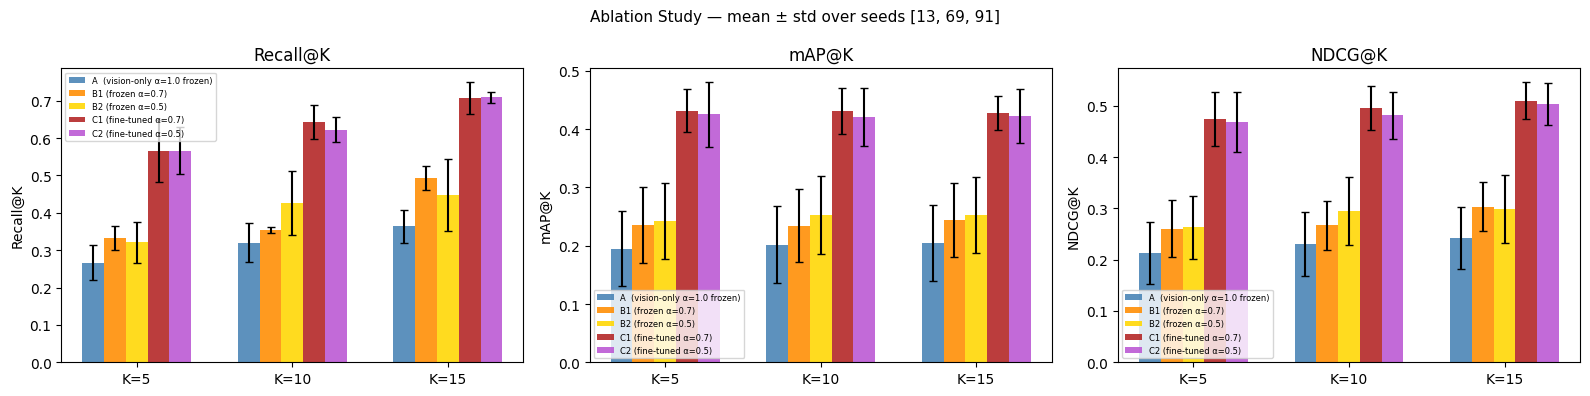

✅ Plot saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_keys   = ["recall_mean", "map_mean", "ndcg_mean"]
metric_stds   = ["recall_std",  "map_std",  "ndcg_std"]
metric_labels = ["Recall@K", "mAP@K", "NDCG@K"]
colors = ["steelblue", "darkorange", "gold", "firebrick", "mediumorchid"]

for ax, mk, ms, ml in zip(axes, metric_keys, metric_stds, metric_labels):
    x = np.arange(len(K_VALUES))
    w = 0.14
    for off, (name, summ), col in zip(
        np.linspace(-0.28, 0.28, len(all_configs)),
        all_configs, colors
    ):
        means = [summ[k][mk] for k in K_VALUES]
        stds  = [summ[k][ms] for k in K_VALUES]
        ax.bar(x + off, means, w, yerr=stds, label=name,
               capsize=3, alpha=0.88, color=col)
    ax.set_xticks(x)
    ax.set_xticklabels([f"K={k}" for k in K_VALUES])
    ax.set_ylabel(ml); ax.set_title(ml)
    ax.legend(fontsize=6)

plt.suptitle("Ablation Study — mean ± std over seeds [13, 69, 91]", fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Study/VR/Final_Project/saved/ablation_results.png", dpi=150)
plt.show()
print("✅ Plot saved to Drive")


## 13. SearchEngine Class — Streamlit Integration
This class wraps the entire pipeline into a clean, reusable API.  
Streamlit app only needs to import this class.


In [ ]:
class SearchEngine:
    """
    End-to-end visual product search engine.

    Usage
    -----
    # --- offline (run once) ---
    engine = SearchEngine.build(
        clip_model, clip_proc, gallery_captions,
        alpha=ALPHA_ABLATION_C, config_name="C"
    )
    engine.save("/content/search_engine_C.pkl")

    # --- online (Streamlit) ---
    engine = SearchEngine.load("/content/search_engine_C.pkl")
    cropped_pil, results = engine.search("query.jpg", k=10, rerank=True)
    """

    def __init__(self, index, metadata, clip_model, clip_proc,
                 blip_processor, blip_model, yolo_model,
                 alpha, device):
        self.index         = index
        self.metadata      = metadata
        self.clip_model    = clip_model
        self.clip_proc     = clip_proc
        self.blip_proc     = blip_processor
        self.blip_model    = blip_model
        self.yolo          = yolo_model
        self.alpha         = alpha
        self.device        = device

    # ── Public API ────────────────────────────────────────────────────────

    def crop(self, image_path: str) -> Image.Image:
        """YOLO-crop a query image. Returns PIL Image."""
        return yolo_crop(image_path)

    def search(self, image_path: str, k: int = 10,
               use_rerank: bool = False,
               query_caption: str = None) -> tuple:
        """
        Full search pipeline.

        Parameters
        ----------
        image_path    : path to query image
        k             : number of results to return
        use_rerank    : apply BLIP-2 ITM re-ranking
        query_caption : optional text caption for query fusion

        Returns
        -------
        cropped_image : PIL.Image  (YOLO crop shown in UI)
        results       : list of dicts
                        {rank, image_name, image_path, item_id, caption, score}
        """
        results = retrieve(
            image_path,
            self.clip_model, self.clip_proc,
            self.index, self.metadata,
            alpha=self.alpha,
            query_caption=query_caption,
            k=k
        )
        if use_rerank:
            results = rerank(image_path, results)

        cropped = self.crop(image_path)
        return cropped, results

    def display_results(self, query_path: str, results: list, k: int = 5):
        """Quick matplotlib display — useful in Colab."""
        cropped = self.crop(query_path)
        fig, axes = plt.subplots(1, k+1, figsize=(4*(k+1), 4))
        axes[0].imshow(cropped); axes[0].set_title("Query"); axes[0].axis("off")
        for i, r in enumerate(results[:k]):
            img = Image.open(r["image_path"])
            axes[i+1].imshow(img)
            axes[i+1].set_title(f"#{r['rank']}\n{r['item_id']}\n{r['score']:.3f}")
            axes[i+1].axis("off")
        plt.tight_layout(); plt.show()

    # ── Factory methods ───────────────────────────────────────────────────

    @classmethod
    def build(cls, clip_model, clip_proc, gallery_cap_map,
              alpha: float, config_name: str):
        """Build from existing clip model and gallery captions."""
        embs, meta = build_gallery_embeddings(
            clip_model, clip_proc, gallery_cap_map,
            alpha=alpha, config_name=config_name
        )
        idx = build_hnsw_index(embs, config_name)
        return cls(idx, meta, clip_model, clip_proc,
                   blip_processor, blip_model, yolo_model,
                   alpha, device)

    def save(self, path: str):
        """Pickle the engine state (no heavy tensors — models saved separately)."""
        state = {
            "metadata": self.metadata,
            "alpha"   : self.alpha,
            "config"  : {
                "clip_model_name": CLIP_MODEL_NAME,
                "blip_model_name": BLIP_MODEL_NAME,
                "yolo_model"     : YOLO_MODEL,
            }
        }
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(state, f)
        # save FAISS index alongside
        faiss.write_index(self.index, path.replace(".pkl", "_index.bin"))
        print(f"✅ SearchEngine state saved → {path}")

    @classmethod
    def load(cls, path: str,
             clip_model=None, clip_proc=None,
             blip_proc=None, blip_mdl=None, yolo_mdl=None):
        """
        Reload engine from saved state.
        Heavy models can be passed in (if already loaded) or
        they will be reloaded from HuggingFace.
        """
        with open(path, "rb") as f:
            state = pickle.load(f)
        idx = faiss.read_index(path.replace(".pkl", "_index.bin"))

        cfg = state["config"]

        if clip_model is None:
            clip_model = CLIPModel.from_pretrained(cfg["clip_model_name"]).to(device)
            clip_model.eval()
        if clip_proc is None:
            clip_proc = CLIPProcessor.from_pretrained(cfg["clip_model_name"])
        if blip_proc is None:
            blip_proc = Blip2Processor.from_pretrained(cfg["blip_model_name"])
        if blip_mdl is None:
            blip_mdl = Blip2ForConditionalGeneration.from_pretrained(
                cfg["blip_model_name"], torch_dtype=torch.float16).to(device)
            blip_mdl.eval()
        if yolo_mdl is None:
            yolo_mdl = YOLO(cfg["yolo_model"])

        return cls(idx, state["metadata"], clip_model, clip_proc,
                   blip_proc, blip_mdl, yolo_mdl, state["alpha"], device)

print("✅ SearchEngine class defined")


✅ SearchEngine class defined


### 13.1 Build & Save Best-Performing Engine (Config C)

In [ ]:
# Build the best engine (Config C: fine-tuned CLIP + BLIP-2)
best_engine = SearchEngine.build(
    clip_ft, clip_ft_proc, gallery_captions,
    alpha=ALPHA_ABLATION_C1, config_name="C"
)
best_engine.save("/content/search_engine_best.pkl")
print("✅ Best engine saved")


Gallery emb config=C:   0%|          | 0/12612 [00:00<?, ?it/s]

✅ Config C: (12612, 512) embeddings saved
✅ HNSW index (12612 vectors) saved → /content/drive/MyDrive/Study/VR/Final_Project/saved/embeddings/index_C.bin
✅ SearchEngine state saved → /content/search_engine_best.pkl
✅ Best engine saved


## 14. Demo Script for Batch Evaluation
Evaluates the best model over a folder of query images and prints all metrics.
This cell can be copy-pasted into a standalone `evaluate.py` script.


In [ ]:
def batch_evaluate(engine: SearchEngine,
                   query_dir: str,
                   gt_map: dict,
                   k_values: list = K_VALUES,
                   use_rerank: bool = False,
                   seed: int = DEFAULT_SEED) -> dict:
    """
    Batch evaluation script for the best-performing model.
    Prints Recall@K, NDCG@K, mAP@K for K in k_values.
    Returns full metrics dict.
    """
    set_seed(seed)
    query_images = [q for q in os.listdir(query_dir) if q in gt_map]
    per_query    = {k: {"recall": [], "map": [], "ndcg": []} for k in k_values}

    for q in tqdm(query_images, desc="Batch evaluation"):
        q_path  = os.path.join(query_dir, q)
        gt_item = gt_map[q]
        q_cap   = query_captions.get(q, None)

        try:
            _, results = engine.search(q_path, k=max(k_values),
                                       use_rerank=use_rerank, query_caption=q_cap)
            for k in k_values:
                top_k = results[:k]
                per_query[k]["recall"].append(recall_at_k(top_k, gt_item))
                per_query[k]["map"].append(average_precision_at_k(top_k, gt_item))
                per_query[k]["ndcg"].append(ndcg_at_k(top_k, gt_item))
        except Exception as e:
            pass

    print("\n" + "="*50)
    print("  BATCH EVALUATION RESULTS (Best Model)")
    print("="*50)
    print(f"{'K':>4}  {'Recall@K':>10}  {'mAP@K':>10}  {'NDCG@K':>10}")
    print("-"*50)
    for k in k_values:
        r = np.mean(per_query[k]["recall"])
        m = np.mean(per_query[k]["map"])
        n = np.mean(per_query[k]["ndcg"])
        print(f"{k:>4}  {r:>10.4f}  {m:>10.4f}  {n:>10.4f}")
    print("="*50) # Added closing separator

    return per_query


# Run it
best_eval = batch_evaluate(best_engine, QUERY_DIR, gt_map,
                           k_values=K_VALUES, use_rerank=False,
                           seed=DEFAULT_SEED)

Batch evaluation:   0%|          | 0/14218 [00:00<?, ?it/s]


  BATCH EVALUATION RESULTS (Best Model)
   K    Recall@K       mAP@K      NDCG@K
--------------------------------------------------
   5      0.6803      0.5311      0.5763
  10      0.7408      0.5125      0.5850
  15      0.7862      0.5030      0.5917
